In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix

In [2]:
df = pd.read_csv('loan_approval_data.csv')

df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [4]:
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

#### Handling Missing Values

- Numerical data - Use mean value
- Categorical data - Use Mode value

In [5]:
categorical_features = df.select_dtypes(include=['object']).columns
# numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
numerical_features = df.select_dtypes(include=['number']).columns

In [6]:
categorical_features

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [7]:
numerical_features

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [8]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='mean')
num_imputer.fit(df[numerical_features])
df[numerical_features] = num_imputer.fit_transform(df[numerical_features])

cat_imputer = SimpleImputer(strategy='most_frequent')
cat_imputer.fit(df[categorical_features])
df[categorical_features] = cat_imputer.fit_transform(df[categorical_features])  

In [9]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [10]:
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

### EDA

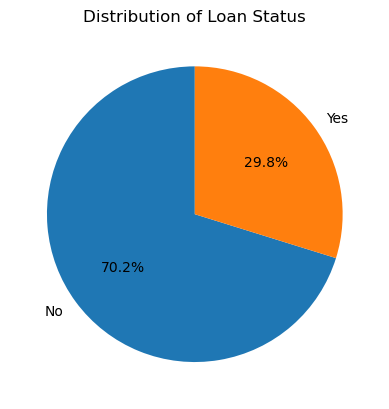

In [12]:
# how balnced is the target variable
target_variable = 'Loan_Approved'

class_counts = df[target_variable].value_counts()
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Loan Status')
plt.show()

#### Analyze categories

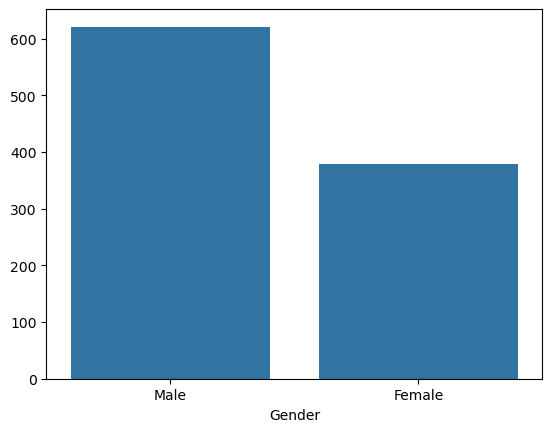

In [15]:
gender_counts = df['Gender'].value_counts()
sns.barplot(x=gender_counts.index, y=gender_counts.values)
plt.show()

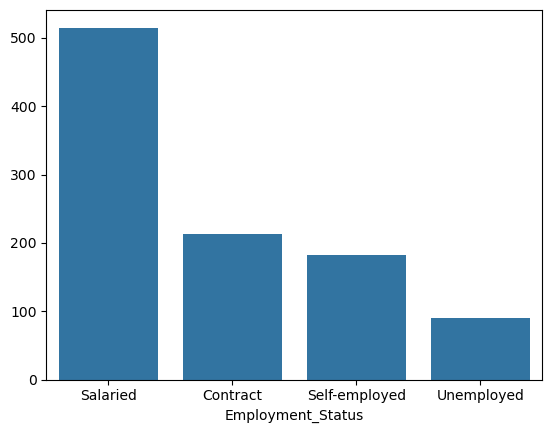

In [17]:
emp_status_counts = df['Employment_Status'].value_counts()
sns.barplot(x=emp_status_counts.index, y=emp_status_counts.values)
plt.show()

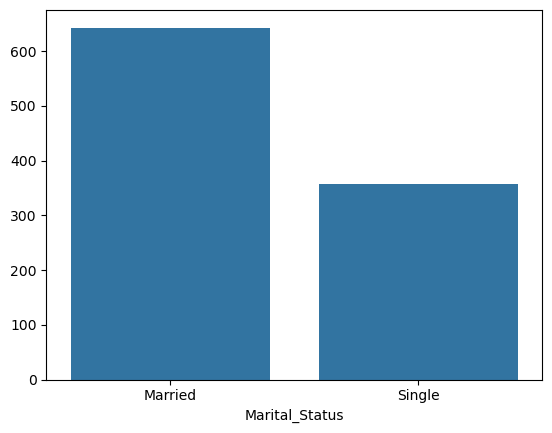

In [20]:
marital_status_counts = df['Marital_Status'].value_counts()
sns.barplot(x=marital_status_counts.index, y=marital_status_counts.values)
plt.show()

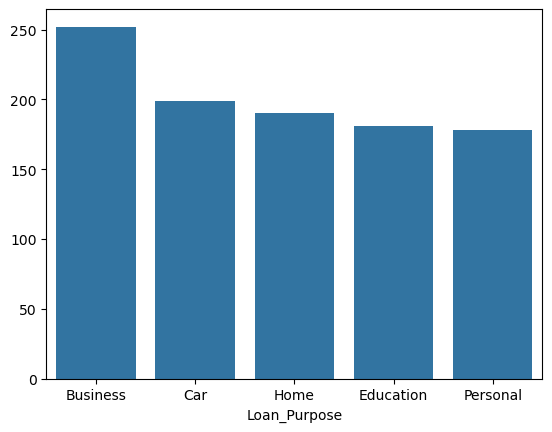

In [26]:
loan_purpose_counts = df['Loan_Purpose'].value_counts()
sns.barplot(x=loan_purpose_counts.index, y=loan_purpose_counts.values)
plt.show()

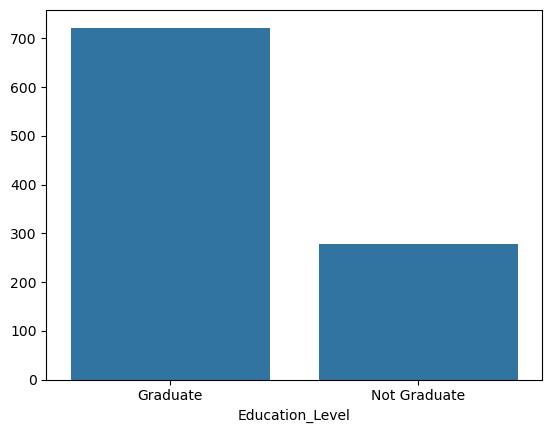

In [27]:
education_counts = df['Education_Level'].value_counts()
sns.barplot(x=education_counts.index, y=education_counts.values)
plt.show()

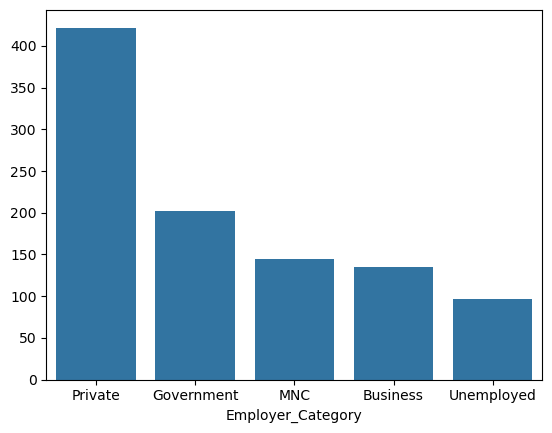

In [28]:
employer_cat_counts = df['Employer_Category'].value_counts()
sns.barplot(x=employer_cat_counts.index, y=employer_cat_counts.values)
plt.show()

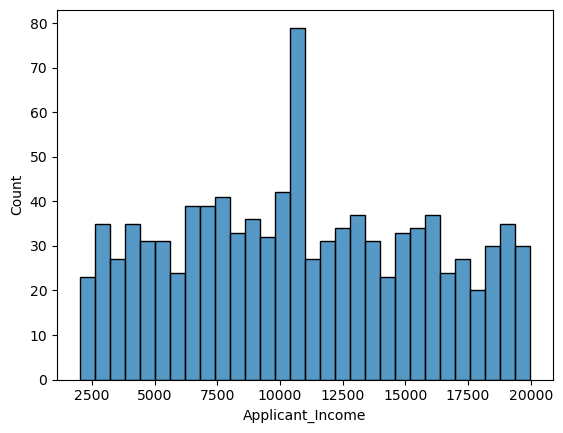

In [30]:
sns.histplot(
    data=df,
    x='Applicant_Income',
    bins=30,
)
plt.show()

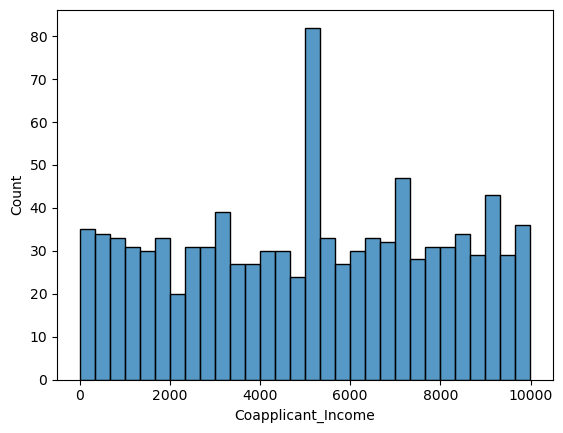

In [31]:
sns.histplot(
    data=df,
    x='Coapplicant_Income',
    bins=30,
)
plt.show()

#### Outlier Detection

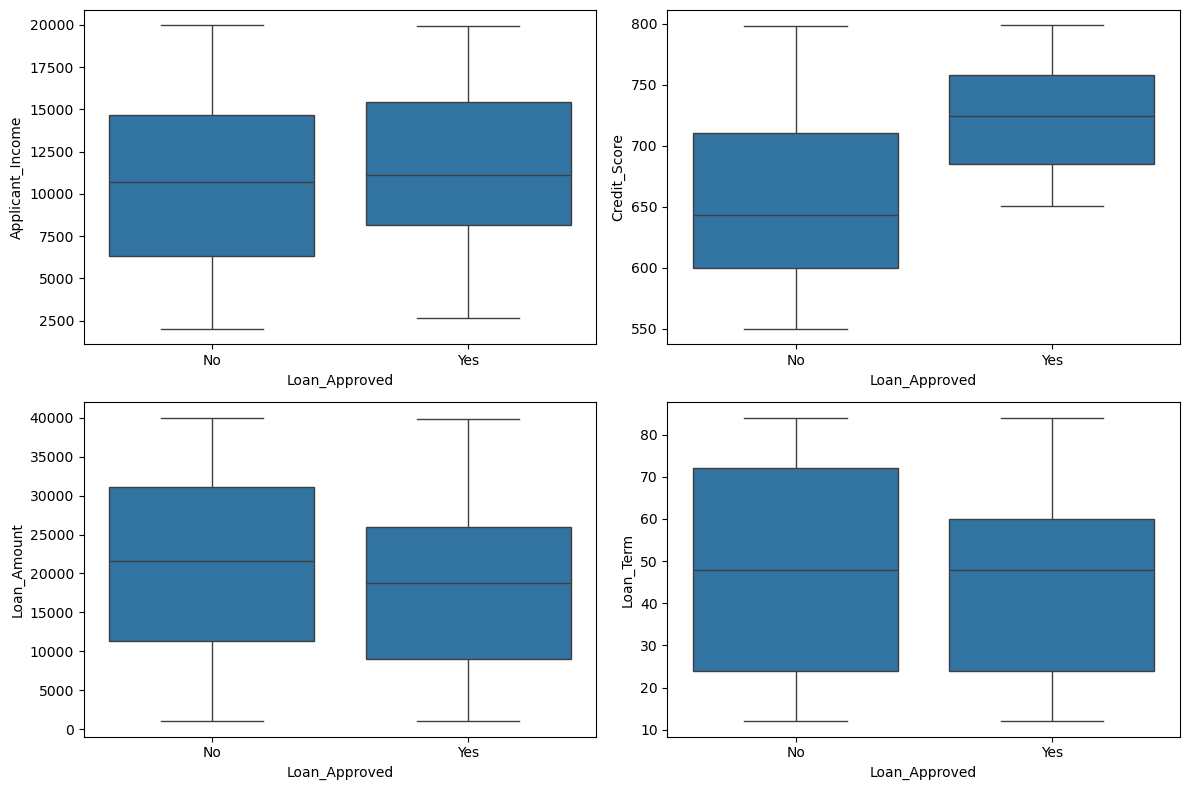

In [40]:
fig,axes = plt.subplots(2,2,figsize=(12,8))
sns.boxplot(ax=axes[0][0], data=df,y='Applicant_Income',x='Loan_Approved')
sns.boxplot(ax=axes[0][1], data=df,y='Credit_Score',x='Loan_Approved')
sns.boxplot(ax=axes[1][0], data=df,y='Loan_Amount',x='Loan_Approved')
sns.boxplot(ax=axes[1][1], data=df,y='Loan_Term',x='Loan_Approved')
plt.tight_layout()
plt.show()


#### In ABove Plot

##### Applicant Income vs Loan Approval
- Median income for Yes is slightly higher.  
- Both groups have almost the same spread.  
- Heavy overlap.

Insight

Higher income slightly increases the chance of loan approval, but income alone is not a strong deciding factor.

Applicant income has only a weak relationship with loan approval.

##### Credit Score vs Loan Approval
- Entire approved distribution is shifted upward.
- Median is much higher.
- Less overlap.

Insight

Applicants with higher credit scores are much more likely to receive loan approval.

This is a strong predictor.

Conclusion

Credit Score is one of the most important variables for predicting loan approval.

##### Loan Term vs Loan Approval
- Both medians are nearly identical.
- Similar spread.
- Almost complete overlap.

Insight- Loan duration doesn't appear to influence approval.

Conclusion- Loan term is probably a weak feature.


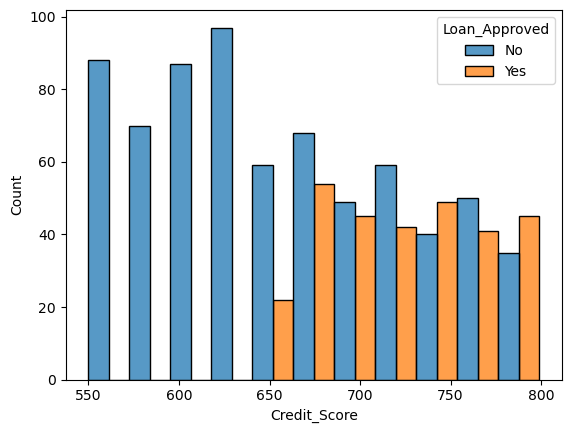

In [48]:
sns.histplot(
    data = df,
    x = "Credit_Score",
    hue = "Loan_Approved",
    multiple = "dodge"
)
plt.show()

##### Above as well we can see score > 650 are likely get get loan approval

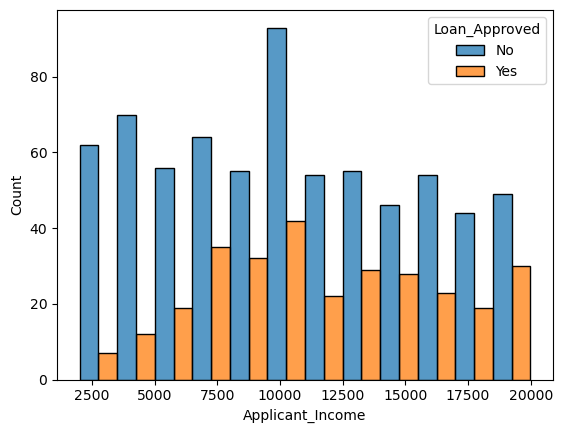

In [49]:
sns.histplot(
    data = df,
    x = "Applicant_Income",
    hue = "Loan_Approved",
    multiple = "dodge"
)
plt.show()

Aboe we see no such direct relation -- but income more than median-higher are getting approval 

In [ ]:
# Remove applicant id
df = df.drop(columns=['Applicant_ID'])

KeyError: "['Applicant_ID'] not found in axis"

In [52]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
